In [83]:
from pathlib import Path
import copy
import math
import os
import sys

import fpsample
import matplotlib.cm as cm
import matplotlib.pyplot as plt\

import numpy as np
import pandas as pd
import scanpy as sc
import scipy as sp
import seaborn as sns
import yaml
from matplotlib.colors import Normalize
from matplotlib.pyplot import rc_context
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import pdist
from tqdm import tqdm

sys.path.insert(0, "../../../../../../shared_utils")
from experiment_utils import manual_filtering

## Initialize columns to keep 

In [84]:
# Cell type fractions
celltype_fraction = {
    "late_MgkPro": 0.10}

columns_of_interest = [
    'gm-csf_[ng_ml]',
     'tpo_[ng_ml]',
     'sr1_[nm]',
     'um171_[nm]',
     'um729_[µm]',
     'scf_[ng_ml]',
     'butyzamide_[nm]',
     'retinoic_acid_[µm]',
     'ldl_[ng_ml]',
     'il3_[ng_ml]',
     'o2_[%]',
     'days_of_culture',
     'run_name',
     "cfg:constraints:c_scheduler_kwargs:t_warmup",
     "cfg:constraints:c_scheduler_kwargs:vmin",
     "cfg:constraints:c_scheduler_kwargs:vmax",

]

new_params = ["il7_[ng_ml]", "mcsf_[ng_ml]", "ly_cocktail_[ul/well]"]

columns_of_interest_l4 =  columns_of_interest + new_params  #+ [ "loss", # "target_ct_loss_std", # "target_ct_loss_mean", # "ct_prop_total_variance"]

## Load solutions 

In [85]:
def load_pure_cell_type_solutions(
    path_to_results,
    paths,
    cell_types,
    load_uncertainties=True
):

    path_to_results = Path(path_to_results)

    pure_cell_type_solution_dict = {
        cell_type: [] for cell_type in cell_types
    }

    for experiment_folder in tqdm(paths):

        cell_type_file_paths = path_to_results / experiment_folder

        if not cell_type_file_paths.exists():
            continue

        # Iterate through cell types
        for cell_type in os.listdir(cell_type_file_paths):

            if cell_type not in cell_types:
                continue

            config_exp_folders = cell_type_file_paths / cell_type

            if not config_exp_folders.is_dir():
                continue

            # Iterate through experiment configs
            for config_exp_folder in os.listdir(config_exp_folders):

                exp_folder = config_exp_folders / config_exp_folder

                if not exp_folder.is_dir():
                    continue

                # Check candidates.csv exists
                if "candidates.csv" not in os.listdir(exp_folder):
                    continue

                if load_uncertainties:
                    uncertainty_path = (
                        exp_folder
                        / "uncertainty_annotation"
                        / "candidates_with_uncertainties.csv"
                    )

                else:
                    uncertainty_path = (
                        exp_folder
                        / "candidates.csv"
                    )

                # Check uncertainty annotation exists
                if uncertainty_path.exists():
 
                    candidate_with_uncertainty_df = pd.read_csv(
                        uncertainty_path
                    )

                    candidate_with_uncertainty_df["run_name"] = [
                        Path(file).name
                        for file in candidate_with_uncertainty_df[
                            "cfg:paths:dump_dir"
                        ]
                    ]

                    pure_cell_type_solution_dict[cell_type].append(
                        candidate_with_uncertainty_df
                    )

    return pure_cell_type_solution_dict

## Read annotation file

In [86]:
# Read annotation files
ANNOTATION_CFG_FILE = "../../../../../../inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]
protocol_cols_l4 = protocol_cols + ['il7_[ng_ml]','mcsf_[ng_ml]','ly_cocktail_[ul/well]']

# Read constraint files
ANNOTATION_CFG_FILE_BOUNDS = "../../../../../../inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound = yaml.safe_load(fb)
ubound_dict, lbound_dict = annotation_cfg_bound["ubound_dict"],  annotation_cfg_bound["lbound_dict"]

ANNOTATION_CFG_FILE_BOUNDS = "../../../../../../inverse/loss_guidance/config/constraints/default_all_cols_loop4.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound_l4 = yaml.safe_load(fb)
ubound_dict_l4, lbound_dict_l4 = annotation_cfg_bound_l4["ubound_dict"],  annotation_cfg_bound_l4["lbound_dict"]

# Collect per parameter bounds 
bounds = {}
for param in lbound_dict:
    bounds[param] = (lbound_dict[param], ubound_dict[param])

bounds_l4 = {}
for param in lbound_dict_l4:
    bounds_l4[param] = (lbound_dict_l4[param], ubound_dict_l4[param])

### Collect optimized samples 

In [87]:
path_to_results_loop4 = Path("../../../../../../project_folder/output/inverse/loss_guidance/loop4_replicate")
paths_loop4 = os.listdir(path_to_results_loop4)

path_to_results_loop2 = Path("../../../../../../project_folder/output/inverse/loss_guidance/loop2p5_replicate_old_clf")
paths_loop2 = os.listdir(path_to_results_loop2)

In [88]:
cell_types = ["late_MgkPro"]

raw_solutions_loop4 = load_pure_cell_type_solutions(
    path_to_results_loop4,
    paths_loop4,
    cell_types,
    load_uncertainties=False
)

raw_solutions_loop2 = load_pure_cell_type_solutions(
    path_to_results_loop2,
    paths_loop2,
    cell_types,
    load_uncertainties=False
)

100%|██████████| 6/6 [00:05<00:00,  1.16it/s]


In [89]:
raw_solutions_loop4 = {
    key: pd.concat(val, axis=0) for key, val in raw_solutions_loop4.items()
}

raw_solutions_loop2 = {
    key: pd.concat(val, axis=0) for key, val in raw_solutions_loop2.items()
}

In [90]:
mgkpro_l2 = raw_solutions_loop2['late_MgkPro']
mgkpro_l4 = raw_solutions_loop4['late_MgkPro']

mgkpro_l2 = mgkpro_l2.reset_index()
mgkpro_l4 = mgkpro_l4.reset_index()

In [91]:
for col in mgkpro_l4.columns:
    print(col)

index
sample_id
gm-csf_[ng_ml]
tpo_[ng_ml]
sr1_[nm]
um171_[nm]
um729_[µm]
scf_[ng_ml]
butyzamide_[nm]
retinoic_acid_[µm]
ldl_[ng_ml]
il3_[ng_ml]
o2_[%]
days_of_culture
il7_[ng_ml]
mcsf_[ng_ml]
ly_cocktail_[ul/well]
gm-csf_[ng_ml]:rescaled
tpo_[ng_ml]:rescaled
sr1_[nm]:rescaled
um171_[nm]:rescaled
um729_[µm]:rescaled
scf_[ng_ml]:rescaled
butyzamide_[nm]:rescaled
retinoic_acid_[µm]:rescaled
ldl_[ng_ml]:rescaled
il3_[ng_ml]:rescaled
o2_[%]:rescaled
days_of_culture:rescaled
il7_[ng_ml]:rescaled
mcsf_[ng_ml]:rescaled
ly_cocktail_[ul/well]:rescaled
loss
CD14Mono_prop
CD16Mono_prop
CyclingPro1_prop
CyclingPro2_prop
Early_GMP_prop
EosBasMast1_prop
EosBasMast2_prop
EosBasMast3_prop
EryPro_prop
GMP-Neutro_prop
GMP_cycling_prop
HSCs_prop
LMPP-CLP_prop
MLP_prop
MPP_prop
MPP_MgkEry_prop
MgKEryPro1_prop
MgKEryPro2_prop
ProB_prop
earlyMPP_prop
late_MgkPro_prop
preProB_prop
pre_cDC1_prop
pre_cDC2_prop
cfg:annotation:protocol_columns
cfg:annotation:protocol_obs_key_added
cfg:annotation:protocol_sep
cfg

# Filter solutions

In [92]:
# Collect filtered and annotated data frames 
filtered_df_mgkpro_l4, annotated_df_mgkpro_l4 = manual_filtering(
    df_dict={"late_MgkPro": mgkpro_l4},
    bounds=bounds_l4,
    columns_to_keep=columns_of_interest_l4, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=0.5, 
    protocol_cols=protocol_cols_l4,
    use_fraction_filter=True, 
    use_oxygen_days_filter=True,
    use_bounds_filter=True
)
mgkpro_l4 = filtered_df_mgkpro_l4["late_MgkPro"]

# Collect filtered and annotated data frames 
filtered_df_mgkpro_l2, annotated_df_mgkpro_l2 = manual_filtering(
    df_dict={"late_MgkPro": mgkpro_l2},
    bounds=bounds,
    columns_to_keep=columns_of_interest, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=0.5, 
    protocol_cols=protocol_cols, 
    use_fraction_filter=True, 
    use_oxygen_days_filter=True,
    use_bounds_filter=True
)
mgkpro_l2 = filtered_df_mgkpro_l2["late_MgkPro"]

## Compare 

In [93]:
f_mgkpro_l4 = filtered_df_mgkpro_l4["late_MgkPro"]
f_mgkpro_l2 = filtered_df_mgkpro_l2["late_MgkPro"]

In [94]:
res_cols_l4 = set(f_mgkpro_l4.columns) - set(protocol_cols_l4)
res_cols_l2 = set(f_mgkpro_l2.columns) - set(protocol_cols)

In [95]:
f_mgkpro_l2.loc[:, new_params] = 0

In [96]:
# f_mgkpro_adata_l2 = sc.AnnData(X=f_mgkpro_l2.loc[:, protocol_cols_l4], obs=f_mgkpro_l2.loc[:,list(res_cols_l2)])
# f_mgkpro_adata_l4 = sc.AnnData(X=f_mgkpro_l4.loc[:, protocol_cols_l4], obs=f_mgkpro_l4.loc[:,list(res_cols_l4)])

f_mgkpro_adata = sc.AnnData(X=np.concat([f_mgkpro_l2.loc[:, protocol_cols_l4], 
                                        f_mgkpro_l4.loc[:, protocol_cols_l4]], axis=0))

f_mgkpro_adata.obs = pd.concat([f_mgkpro_l2.loc[:, protocol_cols_l4], 
                                    f_mgkpro_l4.loc[:,protocol_cols_l4]], axis=0)

f_mgkpro_adata.obs["Loop"] = ["loop2" for _ in range(len(f_mgkpro_l2))] + ["loop4" for _ in range(len(f_mgkpro_l4))]

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [97]:
f_mgkpro_adata.var["protocol_cols"] = protocol_cols_l4

In [98]:
sc.pp.log1p(f_mgkpro_adata)

In [99]:
sc.pp.pca(f_mgkpro_adata)

In [111]:
# get all categories in the 'Loop' column
categories = f_mgkpro_adata.obs['Loop'].astype('category').cat.categories

# start with scanpy's default palette (or define your own for every category)
lut = dict(zip(categories, sc.pl.palettes.default_20))  # or default_28, default_102, etc. depending on how many categories

# override specific categories with your custom colors
lut['loop4'] = '#D47A64'
lut['loop2'] = '#2A9D8F'

/tmp/ipykernel_3749822/3304429969.py:4: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(f_mgkpro_adata, color=[col], save=f'_{col_safe}.png')


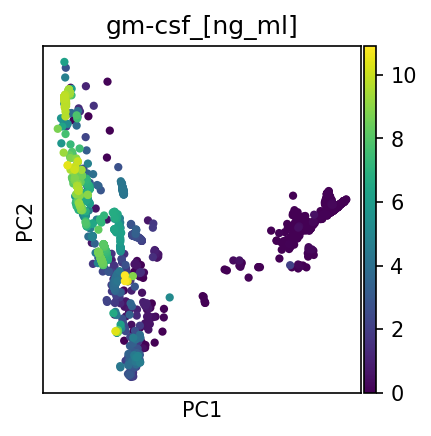

/tmp/ipykernel_3749822/3304429969.py:4: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(f_mgkpro_adata, color=[col], save=f'_{col_safe}.png')


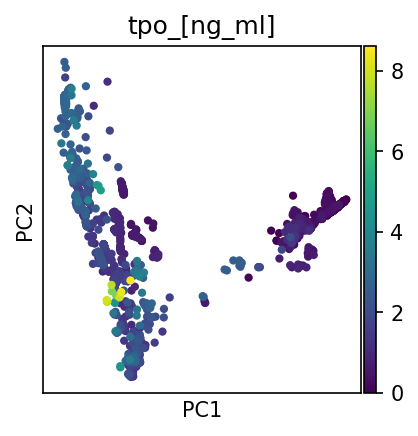

/tmp/ipykernel_3749822/3304429969.py:4: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(f_mgkpro_adata, color=[col], save=f'_{col_safe}.png')


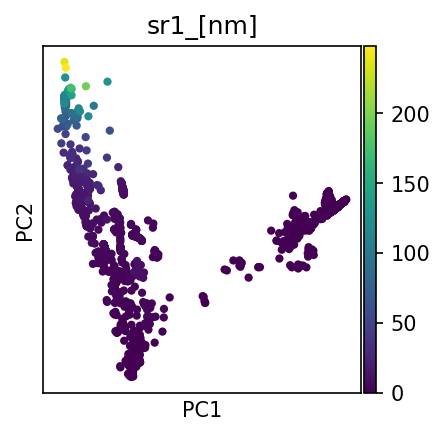

/tmp/ipykernel_3749822/3304429969.py:4: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(f_mgkpro_adata, color=[col], save=f'_{col_safe}.png')


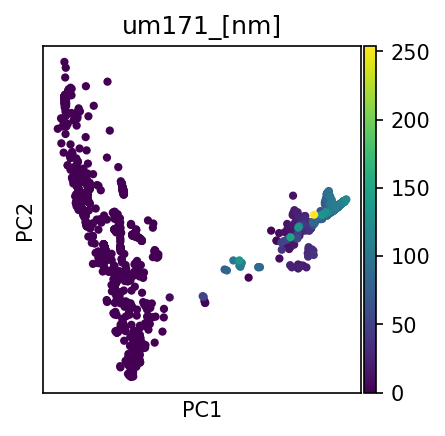

/tmp/ipykernel_3749822/3304429969.py:4: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(f_mgkpro_adata, color=[col], save=f'_{col_safe}.png')


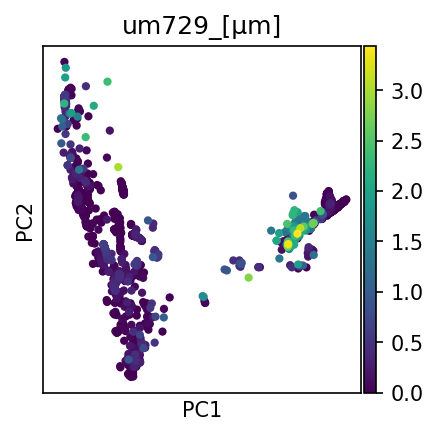

/tmp/ipykernel_3749822/3304429969.py:4: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(f_mgkpro_adata, color=[col], save=f'_{col_safe}.png')


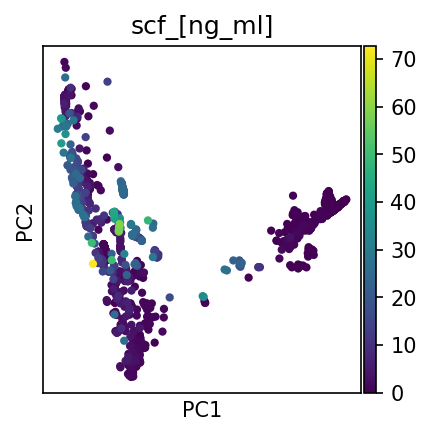

/tmp/ipykernel_3749822/3304429969.py:4: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(f_mgkpro_adata, color=[col], save=f'_{col_safe}.png')


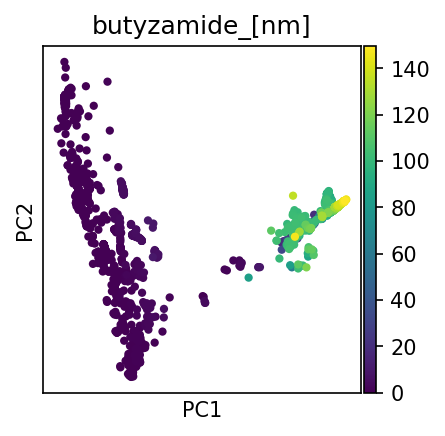

/tmp/ipykernel_3749822/3304429969.py:4: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(f_mgkpro_adata, color=[col], save=f'_{col_safe}.png')


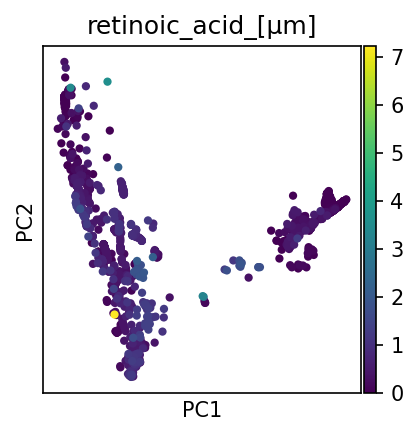

/tmp/ipykernel_3749822/3304429969.py:4: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(f_mgkpro_adata, color=[col], save=f'_{col_safe}.png')


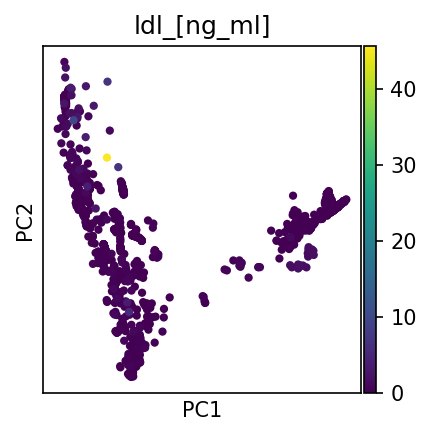

/tmp/ipykernel_3749822/3304429969.py:4: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(f_mgkpro_adata, color=[col], save=f'_{col_safe}.png')


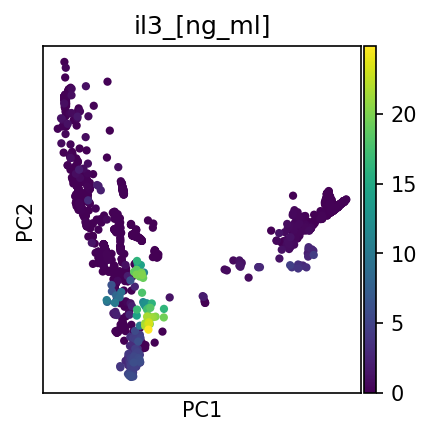

/tmp/ipykernel_3749822/3304429969.py:4: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(f_mgkpro_adata, color=[col], save=f'_{col_safe}.png')


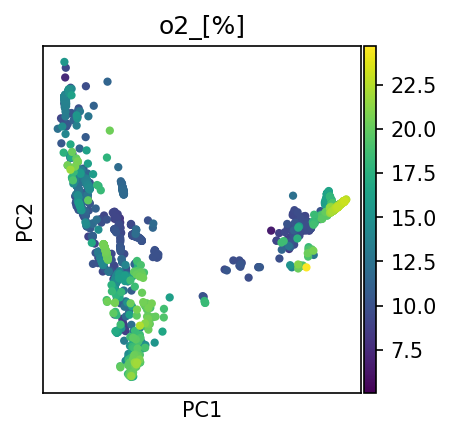

/tmp/ipykernel_3749822/3304429969.py:4: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(f_mgkpro_adata, color=[col], save=f'_{col_safe}.png')


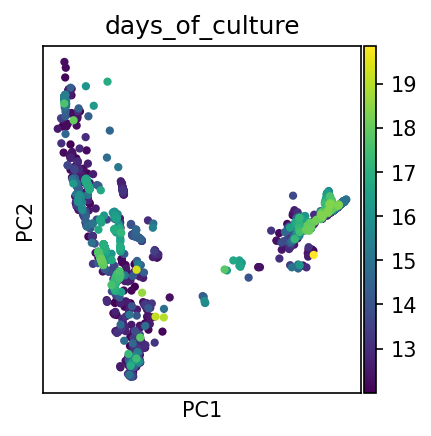

/tmp/ipykernel_3749822/3304429969.py:4: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(f_mgkpro_adata, color=[col], save=f'_{col_safe}.png')


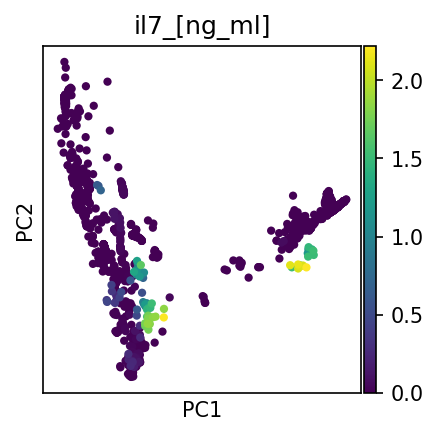

/tmp/ipykernel_3749822/3304429969.py:4: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(f_mgkpro_adata, color=[col], save=f'_{col_safe}.png')


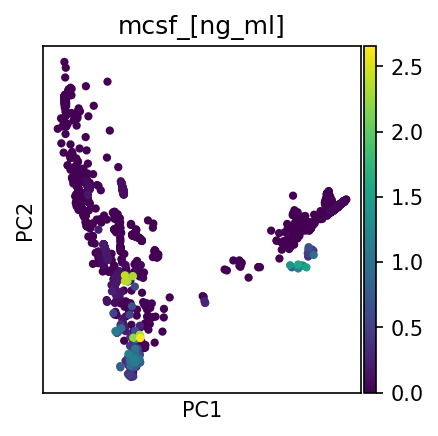

/tmp/ipykernel_3749822/3304429969.py:4: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(f_mgkpro_adata, color=[col], save=f'_{col_safe}.png')


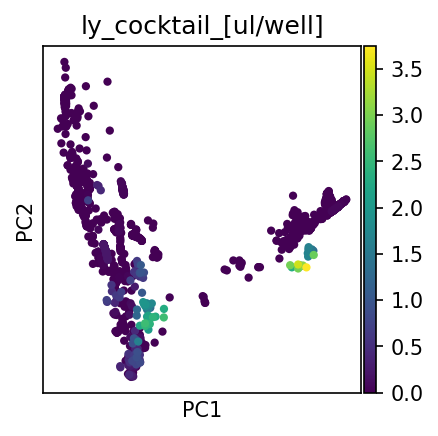

/tmp/ipykernel_3749822/3304429969.py:4: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(f_mgkpro_adata, color=[col], save=f'_{col_safe}.png')


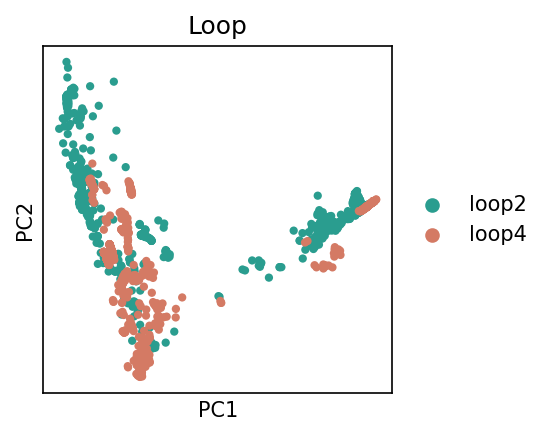

In [110]:
with plt.rc_context({'figure.figsize': (3, 3), 'figure.dpi': 150, 'savefig.dpi': 300}):
    for col in f_mgkpro_adata.obs.columns:
        col_safe = col.replace("/", "-")
        sc.pl.pca(f_mgkpro_adata, color=[col], save=f'_{col_safe}.png')

Index(['loop2', 'loop4'], dtype='object')


/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


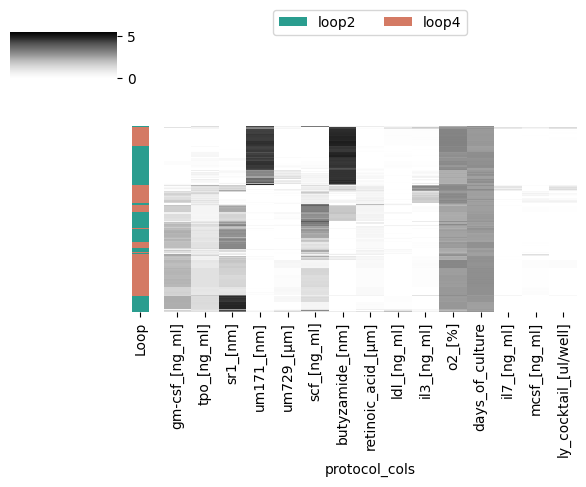

In [102]:
df = pd.DataFrame(
    f_mgkpro_adata.X,
    columns=f_mgkpro_adata.var['protocol_cols'],
    index=f_mgkpro_adata.obs_names
)
loop_categories = f_mgkpro_adata.obs['Loop'].astype('category')
categories = loop_categories.cat.categories
print(categories)  # confirm exact labels, e.g. Index(['loop2', 'loop4'], dtype='object')
palette = sns.color_palette('husl', n_colors=len(categories))
lut = dict(zip(categories, palette))
# Use the EXACT category labels as keys
lut['loop4'] = '#D47A64'
lut['loop2'] = '#2A9D8F'
row_colors = pd.Series(
    [lut[val] for val in loop_categories],
    index=loop_categories.index,
    name='Loop'
)
g = sns.clustermap(
    df,
    row_cluster=True,
    col_cluster=False,
    figsize=(6, 5),
    row_colors=row_colors, 
    cmap="Grays",
    yticklabels=False
)
g.ax_row_dendrogram.set_visible(False)

for label, color in lut.items():
    g.ax_col_dendrogram.bar(0, 0, color=color, label=label, linewidth=0)
g.ax_col_dendrogram.legend(loc='center', ncol=len(lut), bbox_to_anchor=(0.5, 1.2))
plt.savefig("comparison_l2_mgk.png", dpi=500)
plt.tight_layout()
plt.show()